In [201]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad

import time

## Basic Overview
We are trying to solve the Allen-Cahn equation, but not numerically. We will try to see if a **Neural Network** can just learn the solution ϕ(x,t) directly.

### 1) Defining the Neural Network
We are defining the brain of our PINN (Physics Informed Neural Network) the neural network that will take a point (x,t) and output a predicted phase field value ϕ^​. 

Think of it as building a mathematical function approximator whose internal parameters (weights and biases) will be tuned later during training of the NN.

In [202]:
class PINN(nn.Module):
    def __init__(self, layers):     #__init__ is a constructor method that initializes NN architecture.  
        #self is specific instance of class
        #Layers store number of neurons in each layer, including input and output

        super(PINN, self).__init__() #super() refers to parent class (nn.Module) and allows us to call its methods.
        #Helps pytorch to track parameters.
        
        self.network = nn.Sequential() #attribute to hold layers in a sequence.

        for i in range(len(layers) - 1):      #1 less pair than no. of. layers
            self.network.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))   #adds a layer to nn.Sequential container
            #computes y = xA^T + b, where A is weight matrix and b is bias vector
            #For nn.Linear(2,64) takes 2 inputs (x,t), produces 64 neurons 

            if i < len(layers) - 2:     #No activation after last layer
                self.network.add_module(f"tanh_{i}", nn.Tanh())     #Add Tanh activation function after each hidden layer, outputs (-1, 1), helps model learn complex patterns.
    

    def forward(self, x, t):         #forward (special pytorch method) defines how data flows thorugh network

        inputs = torch.cat([x, t], dim=1)  # shape (N, 2), inputs x and t are concatenated along (column) feature dimension (dim=1)
        return self.network(inputs)         # shape:(N, 1), passes concatenated inputs through the network to produce output .

device = torch.device("cpu")

layers = [2, 64, 64, 64, 64, 1]   #input size 2 (x,t), 4 hidden layers with 64 neurons each, output size 1 (ϕ)
model = PINN(layers).to(device)

print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters())}")
#model.parameters() returns an iterator over all learnable tensors (weights and biases) in the network
#p.numel() no. of. elements in each parameter tensor, sum() gives total count of trainable parameters in the model.

PINN(
  (network): Sequential(
    (linear_0): Linear(in_features=2, out_features=64, bias=True)
    (tanh_0): Tanh()
    (linear_1): Linear(in_features=64, out_features=64, bias=True)
    (tanh_1): Tanh()
    (linear_2): Linear(in_features=64, out_features=64, bias=True)
    (tanh_2): Tanh()
    (linear_3): Linear(in_features=64, out_features=64, bias=True)
    (tanh_3): Tanh()
    (linear_4): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total trainable parameters: 12737


## 2) Physics Informed Loss Function
For now the network exists but outputs garbage, basically random weights mean random predictions. 
We have to train it without any data. So what do we target to minimize?
We minimize how badly the network's output violates the Allen-Cahn equation. 
If ϕ​^ is the actual solution, then when you plug it into the PDE the result should be exactly zero everywhere. 
Any deviation from zero is our needed error.

Ww will have 3 error components:
1) PDE Residual loss (PDE) - Sample random (x,t) points inside the domain, then we compute first compute ∂ϕ^/∂t and ∂^2(ϕ^)/∂x^2. 
Putting these into AC equation we can check how far is it from zero.
2) Initial Condition Loss (ICL) -  At t=0, we know what ϕ should look like (for now its a sinusoidal ). Our network should match this perfectly (ideally), error is the mismatch between them.
3) In Boundary Condition Loss (BCL) - At the edges of the domain we will enforce Neumann boundary conditions. 
Basically the spatial derivative at the walls is zero.

In [203]:
def compute_loss(model, x_pde, t_pde, x_ic, t_ic, phi_ic, x_bc, t_bc):
    #1- PDE residual loss
    x_pde.requires_grad_(True)    #tracks tensors  
    t_pde.requires_grad_(True)
    phi = model(x_pde, t_pde) #(N_pde, 1) 
    
    #first derivatives
    phi_t = grad(phi, t_pde, grad_outputs=torch.ones_like(phi), create_graph=True)[0]  #tuple
    phi_x = grad(phi, x_pde, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    
    # Second derivative
    phi_xx = grad(phi_x, x_pde, grad_outputs=torch.ones_like(phi_x), create_graph=True)[0]
    
    # AC residual:dφ/dt - M*(ε²*φ_xx - (φ³ - φ)) = 0
    M = 1.0  #interface mobility, 1 for simplicity
    eps=0.1   #smaller -> sharper interface between phases
    residual = phi_t - (M * (eps**2 * phi_xx - (phi**3 - phi)))   # Any non zero value can be thought of as a physics violation
    lPDE = torch.mean(residual**2)
    
    # 2 - Initial condition loss
    phi_ic_pred = model(x_ic, t_ic)
    lIC = torch.mean((phi_ic_pred - phi_ic)**2)   #average for standard MSE loss
    
    #3 - Boundary condition loss (Neumann: dφ/dx = 0 at x=0 and x=1)
    x_bc.requires_grad_(True)    #again enabling tracking
    phi_bc = model(x_bc, t_bc)  
    phi_bc_x  = grad(phi_bc, x_bc, grad_outputs=torch.ones_like(phi_bc), create_graph=True)[0]
    lBC=torch.mean(phi_bc_x**2)  #0, is Neumann boundary condition is satisfied    
    
    #Total Loss (sum of all 3)
    totalLoss = lPDE + lIC + lBC 
    return totalLoss, lPDE, lIC, lBC

In [204]:
#Domain parameters
N_pde = 5000  #interior collocation points
N_ic  = 300 #initial condition points
N_bc  = 300 #boundary points (250 per side)

x_pde = torch.rand(N_pde, 1)  #PDE points, random (x,t) in domain. x ∈ [0, 1]
t_pde = torch.rand(N_pde, 1) #t ∈ [0, 1]

# Initial condition points: t = 0, φ(x,0) = 0.05*sin(2πx)
x_ic  = torch.rand(N_ic, 1)
t_ic  = torch.zeros(N_ic, 1) # t= 0
phi_ic = 0.05 * torch.sin(2 * torch.pi * x_ic)  #known initial profile

#boundary points: x = 0 and x = 1
t_bc_vals = torch.rand(N_bc, 1)
x_left    = torch.zeros(N_bc // 2, 1)
x_right   = torch.ones(N_bc // 2, 1)
x_bc      = torch.cat([x_left, x_right], dim=0)
t_bc      = torch.cat([t_bc_vals[:N_bc//2], t_bc_vals[N_bc//2:]], dim=0)

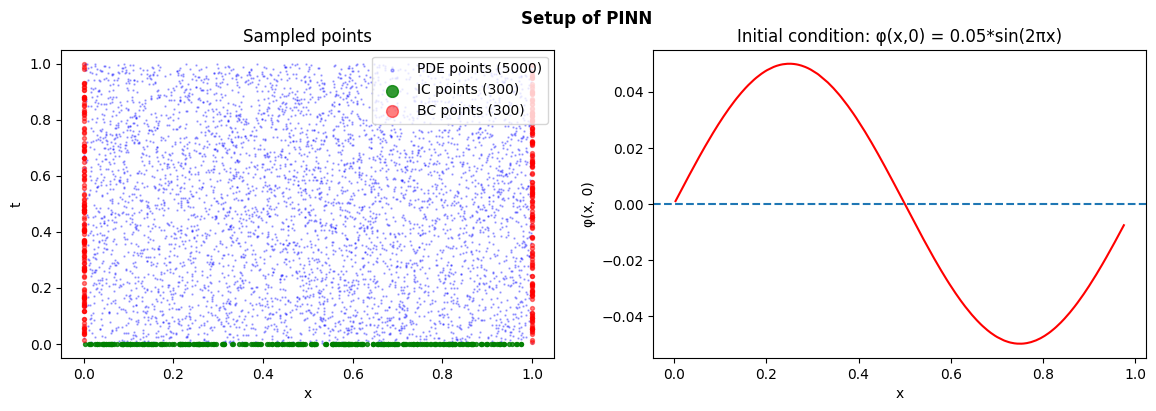

In [205]:
#Visualize the setup of PINN
fig, axes = plt.subplots(1,2, figsize=(14, 4))
fig.suptitle("Setup of PINN", fontweight='bold')

#1: Collocation points in (x,t) domain
ax1 = axes[0]
ax1.scatter(x_pde.detach().numpy(), t_pde.detach().numpy(),
            s=0.5, color='blue', alpha=0.3, label=f'PDE points ({N_pde})')
ax1.scatter(x_ic.detach().numpy(), t_ic.detach().numpy(),
            s=8, color='green', alpha=0.8, label=f'IC points ({N_ic})')
ax1.scatter(x_bc.detach().numpy(), t_bc.detach().numpy(),
            s=8, color='red', alpha=0.5, label=f'BC points ({N_bc})')
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_title("Sampled points")
ax1.legend(markerscale=3)

#Initial condition profile φ(x,0)
ax2 = axes[1]
x_plot = x_ic.detach().numpy()
phi_plot = phi_ic.detach().numpy()
sorted_idx = x_plot[:, 0].argsort()
ax2.plot(x_plot[sorted_idx], phi_plot[sorted_idx], color='red')
ax2.axhline(0,linestyle='--')
ax2.set_xlabel("x")
ax2.set_ylabel("φ(x, 0)")
ax2.set_title("Initial condition: φ(x,0) = 0.05*sin(2πx)")

plt.show()

# Coming to training our PINN

Now we run the training loop. The optimizer will repeatedly call `compute_loss()`, and update the weights to reduce this loss. 

By the end, the network will have learned to approximate $\phi(x, t)$ purely from physics.

In [ ]:
#Hyperparameters 
epochs_adam  = 3000    #no. of times Adam updates weights, more epochs -> better convergence but longer training time
lr_adam      = 1e-5    #learning rate, how big each weight update step is, smaller - stable, slower convergence; larger - faster, risk of overshooting minima